# Pertemuan 12 — Asosiasi Data & Sistem Rekomendasi Dasar

**Mata Kuliah:** Pengantar Data Science (Kode: 200302305)  
**Program Studi:** PJJ Informatika  
**Semester:** 4  
**Dosen:** Syahid Abdullah, S.Si, M.Kom

---

**Nama :** Junior Dany Wibisono  
**NIM  :** 250401020098  
**Kelas :** IF401  
**Angkatan:** 2025  
**Tanggal:** 10 Juli 2026

---

## Tujuan Notebook
Aktivitas hands-on Pertemuan 12 mengintegrasikan dua topik **Unsupervised Learning** yang saling melengkapi:

1. **Association Rule Mining (Market Basket Analysis)** — menemukan pola "jika membeli A, maka cenderung membeli B" dari data transaksi toko menggunakan algoritma **Apriori** (library `mlxtend`), lalu menyaring aturan dengan tiga metrik kunci: **Support, Confidence, & Lift**.
2. **Sistem Rekomendasi Dasar** — membangun rekomender sederhana berbasis **Content-Based Filtering** menggunakan **cosine similarity** atas kategori produk, kemudian **membandingkannya** dengan rekomendasi hasil association rules.

Melanjutkan Pertemuan 11 (Clustering), kedua teknik ini juga bekerja **tanpa label** — kali ini fokusnya pada **pola pembelian bersama** dan **kemiripan item**, bukan pengelompokan pelanggan.

## Langkah 0 — Setup Library

Import semua library yang dibutuhkan. `mlxtend` (*machine learning extensions*) menyediakan fungsi siap pakai `TransactionEncoder`, `apriori`, dan `association_rules` sehingga kita tidak perlu mengimplementasikan algoritma Apriori dari nol. Di Google Colab, `mlxtend` biasanya sudah tersedia; baris `pip install` di bawah menjaga agar notebook tetap reprodusibel bila versinya belum ada.

In [11]:
# Pasang mlxtend bila belum tersedia (aman dijalankan ulang di Colab)
# !pip install mlxtend -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)          # kunci seed agar dataset sintetis reprodusibel
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

print('Setup selesai. Semua library siap digunakan.')

Setup selesai. Semua library siap digunakan.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Langkah 1 — Generate & Eksplorasi Dataset Transaksi

Kita buat **50 transaksi belanja sintetis**, tiap transaksi berisi **2–5 produk** dari 10 produk yang tersedia. Agar Apriori punya pola nyata untuk ditemukan, kita **suntikkan pola tersembunyi**: pada sebagian transaksi awal, jika ada **Roti** maka **Selai** ikut ditambahkan. Nanti kita uji apakah Apriori bisa menemukan kembali pola `Roti → Selai` ini **tanpa diberi tahu**.

> Pendekatan sintetis dipakai supaya notebook reprodusibel tanpa file eksternal — sama seperti dataset segmentasi pelanggan di Pertemuan 11.

In [12]:
# Langkah 1: Bangun 50 transaksi sintetis dengan pola pembelian tersembunyi
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Tiap transaksi berisi 2-5 produk unik yang dipilih acak
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)                       # 2 sampai 5 item
    item = list(np.random.choice(produk, n_item, replace=False))
    transaksi.append(item)

# Suntikkan pola tersembunyi: Roti sering dibeli bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Jumlah transaksi :', len(transaksi))
print('Contoh 5 transaksi pertama:')
for i, t in enumerate(transaksi[:5], 1):
    print(f'  Transaksi {i}: {t}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Jumlah transaksi : 50
Contoh 5 transaksi pertama:
  Transaksi 1: [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
  Transaksi 2: [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
  Transaksi 3: [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]
  Transaksi 4: [np.str_('Selai'), np.str_('Keju'), np.str_('Telur'), np.str_('Teh')]
  Transaksi 5: [np.str_('Mentega'), np.str_('Susu'), np.str_('Gula'), np.str_('Keju')]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

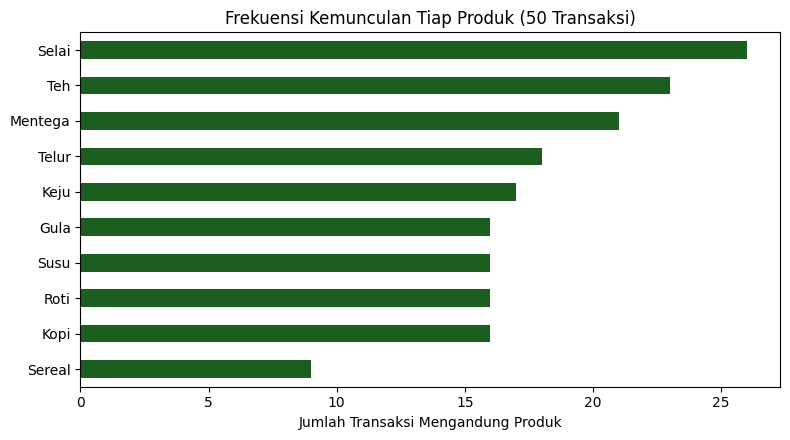

Selai      26
Teh        23
Mentega    21
Telur      18
Keju       17
Roti       16
Kopi       16
Susu       16
Gula       16
Sereal      9
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
# Eksplorasi: frekuensi kemunculan tiap produk di seluruh transaksi
frekuensi = pd.Series([item for t in transaksi for item in t]).value_counts()

plt.figure(figsize=(8, 4.5))
frekuensi.sort_values().plot(kind='barh', color='#1B5E20')
plt.title('Frekuensi Kemunculan Tiap Produk (50 Transaksi)')
plt.xlabel('Jumlah Transaksi Mengandung Produk')
plt.tight_layout()
plt.show()

print(frekuensi)

**Bacaan EDA:**
- Karena pola `Roti → Selai` sengaja ditanam, **Roti** dan **Selai** cenderung muncul lebih sering dibanding produk lain. Ini bukan kebocoran data — justru inilah "sinyal" yang harusnya bisa ditemukan kembali oleh Apriori lewat metrik **Lift**.
- Produk lain tersebar cukup merata karena dipilih acak, sehingga tidak akan membentuk aturan asosiasi yang kuat (Lift-nya mendekati 1).

## Langkah 2 — One-Hot Encoding Transaksi

Apriori bekerja pada **tabel biner (one-hot)**: setiap baris = satu transaksi, setiap kolom = satu produk, nilainya `True`/`False` menandakan apakah produk ada di transaksi tersebut. `TransactionEncoder` dari `mlxtend` mengurus konversi ini secara otomatis dari daftar transaksi mentah.

In [14]:
# Langkah 2: Ubah daftar transaksi menjadi tabel one-hot encoding
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)

print('Ukuran tabel one-hot:', df.shape, '(50 transaksi x 10 produk)')
df.head()

Ukuran tabel one-hot: (50, 10) (50 transaksi x 10 produk)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Langkah 3 — Cari Frequent Itemset dengan Apriori

`apriori()` mencari semua **frequent itemset** — kombinasi produk yang kemunculannya (**Support**) di atas ambang `min_support`. Kita coba **beberapa nilai `min_support`** untuk melihat *trade-off*-nya:

- **`min_support` terlalu kecil** → banyak itemset ditemukan (termasuk *noise* & kombinasi acak), komputasi lebih berat.
- **`min_support` terlalu besar** → hanya sedikit itemset lolos, pola penting bisa terlewat.

Tujuannya memilih nilai yang menghasilkan jumlah itemset **wajar** (tidak 0, tidak ratusan).

In [15]:
# Langkah 3a: Amati dampak pemilihan min_support terhadap jumlah itemset
for ms in [0.05, 0.1, 0.2, 0.3]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f'min_support={ms:<4}: {len(freq):>3} frequent itemset ditemukan')

min_support=0.05:  74 frequent itemset ditemukan
min_support=0.1 :  44 frequent itemset ditemukan
min_support=0.2 :  13 frequent itemset ditemukan
min_support=0.3 :   9 frequent itemset ditemukan


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [16]:
# Langkah 3b: Pilih min_support=0.1 (jumlah itemset wajar), urutkan dari support tertinggi
freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False).reset_index(drop=True)

# Kolom bantu: jumlah item per itemset (1 = item tunggal, 2 = pasangan, dst.)
freq_items['jumlah_item'] = freq_items['itemsets'].apply(len)

print(f'Total frequent itemset (min_support=0.1): {len(freq_items)}')
freq_items.head(12)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total frequent itemset (min_support=0.1): 44


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets,jumlah_item
0,0.52,(Selai),1
1,0.46,(Teh),1
2,0.42,(Mentega),1
3,0.36,(Telur),1
4,0.34,(Keju),1
5,0.32,(Gula),1
6,0.32,(Kopi),1
7,0.32,(Roti),1
8,0.32,(Susu),1
9,0.24,"(Selai, Teh)",2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Bacaan frequent itemset:**
- Itemset dengan **Support tertinggi** umumnya adalah **item tunggal** yang sering muncul (mis. `{Roti}`, `{Selai}`), lalu diikuti **pasangan** seperti `{Roti, Selai}`.
- Support `{Roti, Selai}` yang relatif tinggi adalah jejak dari pola yang kita tanam di Langkah 1. Namun Support **belum cukup** untuk menyimpulkan aturan bermakna — kita butuh **Confidence** dan **Lift** di langkah berikutnya.

## Langkah 4 — Bentuk & Saring Aturan Asosiasi

Dari frequent itemset, `association_rules()` membentuk aturan **if–then** (`antecedents → consequents`) lengkap dengan Confidence & Lift. Kita saring dengan dua kriteria:

- **`min_confidence = 0.5`** → minimal 50% pembeli antecedent juga membeli consequent.
- **`Lift > 1`** → memastikan hubungan A–B **bukan sekadar kebetulan** (berkorelasi positif, bukan karena consequent kebetulan populer).

Hasil akhir diurutkan dari **Lift tertinggi** = aturan paling kuat.

In [17]:
# Langkah 4: Bentuk aturan asosiasi, saring dengan confidence & lift, urutkan by lift
rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False).reset_index(drop=True)

# Rapikan kolom antecedents/consequents (frozenset -> string) agar mudah dibaca
tampil = rules.copy()
tampil['antecedents'] = tampil['antecedents'].apply(lambda x: ', '.join(sorted(x)))
tampil['consequents'] = tampil['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'Jumlah aturan lolos (confidence>=0.5 & lift>1): {len(rules)}')
tampil[['antecedents', 'consequents', 'support', 'confidence', 'lift']].round(3).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Jumlah aturan lolos (confidence>=0.5 & lift>1): 16


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
0,"Keju, Teh",Telur,0.12,0.857,2.381
1,"Mentega, Selai",Kopi,0.10,0.625,1.953
2,"Gula, Roti",Selai,0.10,1.000,1.923
3,Sereal,Mentega,0.14,0.778,1.852
4,"Teh, Telur",Keju,0.12,0.600,1.765
5,"Kopi, Selai",Mentega,0.10,0.714,1.701
6,"Keju, Telur",Teh,0.12,0.750,1.630
7,"Gula, Selai",Roti,0.10,0.500,1.562
8,"Kopi, Mentega",Selai,0.10,0.714,1.374
9,Roti,Selai,0.22,0.688,1.322


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Bacaan aturan asosiasi:**
- Aturan dengan **Lift tertinggi** adalah kandidat terkuat untuk dipakai (mis. penataan rak toko atau rekomendasi *"pelanggan yang membeli ini juga membeli..."*).
- Jika aturan **`Roti → Selai`** muncul di baris atas dengan **Lift > 1** dan **Confidence tinggi**, berarti Apriori **berhasil menemukan kembali pola tersembunyi** yang kita tanam di Langkah 1 — murni dari data, tanpa diberi tahu.
- **Confidence tinggi saja tidak cukup**: sebuah aturan bisa punya Confidence besar hanya karena consequent-nya populer. **Lift**-lah yang memvalidasi bahwa hubungannya nyata.

## Langkah 5 — Rekomender Sederhana dengan Content-Based Filtering

Berbeda dari association rules (berbasis **pola transaksi**), **Content-Based Filtering** merekomendasikan item berdasarkan **kemiripan atribut item itu sendiri**. Kita bangun katalog produk berisi **kategori**, ubah kategori menjadi vektor **one-hot**, lalu ukur kemiripan antar produk dengan **cosine similarity**.

Analogi: *"karena kamu suka produk kategori Bakery, ini produk Bakery lain yang mirip"* — murni dari atribut, tanpa melihat siapa membeli apa.

In [18]:
# Langkah 5a: Bangun katalog produk dengan kategori, hitung matriks kemiripan
katalog = pd.DataFrame({
    'produk':   produk,
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy']
})

# One-hot encoding kategori -> vektor fitur tiap produk
fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

print('Katalog produk:')
print(katalog.to_string(index=False))

Katalog produk:
 produk kategori
   Roti   Bakery
  Selai   Bakery
   Susu    Dairy
 Sereal   Bakery
  Telur    Dairy
   Keju    Dairy
   Kopi  Minuman
   Gula    Bumbu
    Teh  Minuman
Mentega    Dairy


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
# Langkah 5b: Fungsi rekomendasi produk serupa berdasarkan cosine similarity kategori
def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    # urutkan dari paling mirip, buang produk itu sendiri
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

# Uji untuk beberapa produk
for p in ['Roti', 'Susu', 'Kopi']:
    print(f'Mirip dengan {p:<5}:', rekomendasi_serupa(p))

Mirip dengan Roti : ['Selai', 'Sereal', 'Susu']
Mirip dengan Susu : ['Telur', 'Keju', 'Mentega']
Mirip dengan Kopi : ['Teh', 'Roti', 'Selai']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Bacaan Content-Based:**
- Rekomendasi didasarkan **murni pada kategori**: produk Bakery merekomendasikan Bakery lain (`Roti → Selai, Sereal`), produk Dairy merekomendasikan Dairy lain, dst.
- Kelebihan pendekatan ini: **tidak butuh data pengguna lain** dan **kebal *cold start*** untuk item baru (asal atributnya diketahui). Kelemahannya: rekomendasi **kurang beragam** — cenderung menyarankan yang mirip dengan yang sudah disukai (*filter bubble*).

## Langkah 6 — Bandingkan Kedua Pendekatan

Sekarang kita bandingkan rekomendasi untuk produk yang sama dari **dua sudut pandang berbeda**:

| Pendekatan | Dasar rekomendasi | Sumber data |
|---|---|---|
| **Association Rules** | pola *pembelian bersama* | data transaksi |
| **Content-Based** | *kemiripan atribut* item | katalog produk |

In [20]:
# Langkah 6: Bandingkan rekomendasi untuk produk target yang sama
produk_target = 'Roti'

# (A) Dari Association Rules: consequents dari aturan yang antecedent-nya mengandung produk_target
rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)].copy()
rules_terkait['consequents'] = rules_terkait['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'=== Rekomendasi untuk "{produk_target}" ===\n')
print('(A) Dari ASSOCIATION RULES (pola beli bersama):')
if len(rules_terkait):
    print(rules_terkait[['consequents', 'confidence', 'lift']].round(3).to_string(index=False))
else:
    print('  (tidak ada aturan lolos untuk produk ini)')

# (B) Dari Content-Based Filtering: produk dengan kategori paling mirip
print('\n(B) Dari CONTENT-BASED (kemiripan kategori):')
print(' ', rekomendasi_serupa(produk_target))

=== Rekomendasi untuk "Roti" ===

(A) Dari ASSOCIATION RULES (pola beli bersama):
consequents  confidence  lift
      Selai       1.000 1.923
      Selai       0.688 1.322

(B) Dari CONTENT-BASED (kemiripan kategori):
  ['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Bacaan perbandingan:**
- **Association Rules** menyarankan produk yang *nyata dibeli bersama* Roti dalam data (mis. **Selai**) — berguna untuk *cross-selling* dan penataan rak.
- **Content-Based** menyarankan produk yang *kategorinya mirip* Roti (sesama Bakery) — berguna saat belum ada histori pembelian (*cold start*).
- Keduanya bisa **konsisten** (mis. sama-sama menyarankan Selai bila Selai juga Bakery) atau **saling melengkapi**. Dalam praktik, sistem produksi seperti **Netflix, Amazon, Spotify** menggabungkan keduanya menjadi **sistem Hybrid** agar kelemahan satu pendekatan (cold start pada Collaborative, kurang beragam pada Content-Based) ditutupi oleh kekuatan pendekatan lain.

## Langkah 7 — Simpan Notebook & Upload ke GitHub

Setelah semua sel dijalankan (**Runtime → Run all** memberi hasil bersih dari atas ke bawah), simpan notebook dengan penamaan sesuai ketentuan, lalu upload ke GitHub dan submit link ke **Forum Diskusi 12** di LMS.

```
Nama file : Pertemuan12_JuniorDanyWibisono_250401020098.ipynb
Repo      : https://github.com/juniordw/data-science-2026
```

## Kesimpulan & Refleksi

Pertemuan ini menyatukan dua teknik **Unsupervised Learning** yang berorientasi pada **pola** dan **kemiripan**, bukan pengelompokan seperti clustering di Pertemuan 11:

1. **Association Rule Mining (Apriori)** menemukan pola *"jika A maka B"* dari data transaksi tanpa label. Kuncinya bukan sekadar seberapa sering (**Support**) atau seberapa yakin (**Confidence**), melainkan **Lift** — yang membedakan hubungan **nyata** dari **kebetulan statistik**. Apriori berhasil menemukan kembali pola `Roti → Selai` yang sengaja saya tanam, membuktikan algoritma menangkap struktur data secara murni.
2. **Apriori Principle (*downward closure*)** — "jika sebuah itemset tidak frequent, semua supersetnya juga pasti tidak frequent" — adalah trik yang membuat pencarian tetap efisien meski jumlah kombinasi itemset bisa mencapai 2ⁿ.
3. **Content-Based Filtering** merekomendasikan item dari **kemiripan atribut** (cosine similarity atas kategori), unggul saat *cold start* karena tidak butuh histori pengguna lain — tetapi cenderung menghasilkan rekomendasi yang kurang beragam.
4. **Association Rules vs Content-Based** menjawab pertanyaan berbeda: yang satu *"apa yang dibeli bersama?"*, yang lain *"apa yang mirip?"*. Sistem rekomendasi modern menggabungkan keduanya (**Hybrid**) untuk hasil terbaik.

Pelajaran terpenting: sama seperti clustering, di sini **tidak ada Accuracy** untuk diandalkan. Kualitas association rules diukur dari **Lift** dan **kelayakan bisnis**, sedangkan kualitas rekomendasi diukur dari metrik **Top-K** seperti **Precision@K** (proporsi item relevan di antara K rekomendasi teratas).

---
**Keterbatasan & Pertanyaan Lanjutan:**
- Dataset **sintetis** berukuran kecil (50 transaksi) dengan pola yang sengaja ditanam — kondisi ideal. Pada data ritel nyata yang besar dan *sparse*, pemilihan `min_support` jauh lebih menantang, dan **FP-Growth** sering lebih cepat daripada Apriori.
- Content-Based di sini hanya memakai **satu atribut (kategori)**. Sistem nyata memakai fitur kaya (genre, deskripsi via **TF-IDF**, harga, merek).
- Langkah berikutnya yang ingin saya pelajari: **Collaborative Filtering** (user-based & item-based) pada *user-item matrix* nyata, **Matrix Factorization** (SVD), evaluasi dengan **Precision@K / Recall@K**, serta membangun **sistem Hybrid** yang menggabungkan Collaborative + Content-Based.